# Task 5: Personal Loan Acceptance Prediction

## Objective
Predict which customers are likely to accept a personal loan offer
based on features like age, job, marital status, and account balance.

## Dataset
Bank Marketing Dataset (UCI) — contains 11,162 records with customer
demographic and banking information.

In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the dataset
df = pd.read_csv('bank.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (11162, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
# Check data types and missing values
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB

Missing Values:
age          0
job          0
marital      0
education    0
default 

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


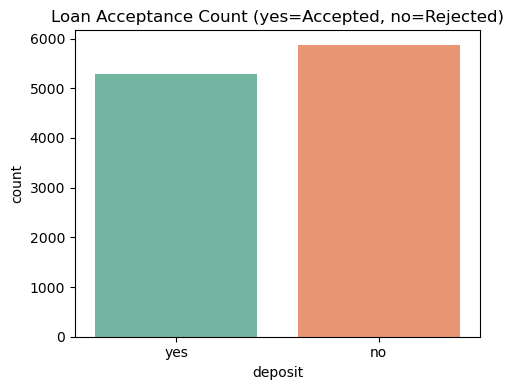

In [4]:
# Plot 1: Loan Acceptance Count
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='deposit', palette='Set2')
plt.title('Loan Acceptance Count (yes=Accepted, no=Rejected)')
plt.tight_layout()
plt.savefig('loan_acceptance_count.png')
plt.show()

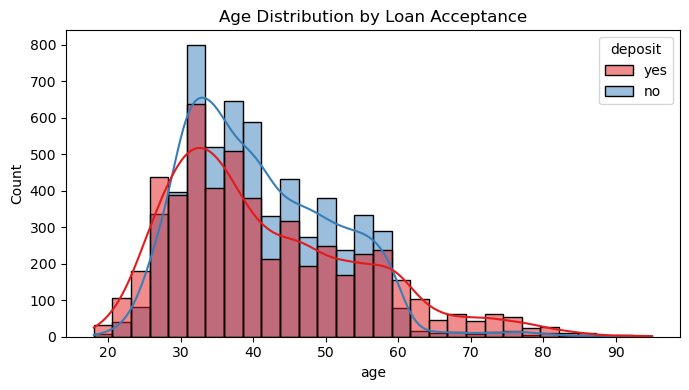

In [5]:
# Plot 2: Age Distribution by Loan Acceptance
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x='age', hue='deposit', bins=30, kde=True, palette='Set1')
plt.title('Age Distribution by Loan Acceptance')
plt.tight_layout()
plt.savefig('age_distribution.png')
plt.show()

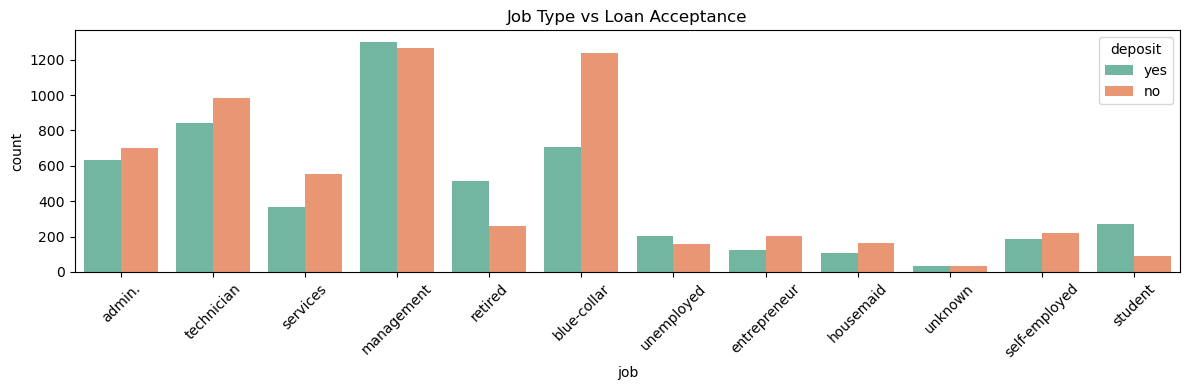

In [6]:
# Plot 3: Job vs Loan Acceptance
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='job', hue='deposit', palette='Set2')
plt.title('Job Type vs Loan Acceptance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('job_vs_loan.png')
plt.show()

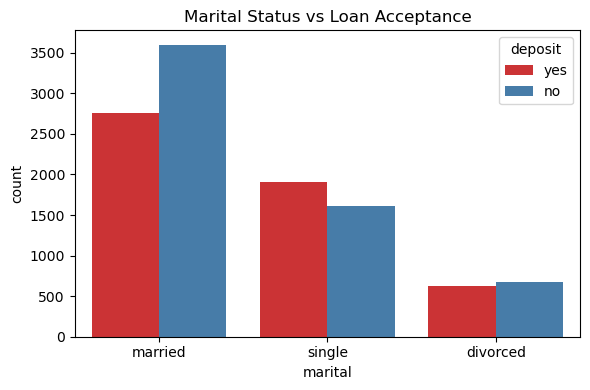

In [7]:
# Plot 4: Marital Status vs Loan Acceptance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='marital', hue='deposit', palette='Set1')
plt.title('Marital Status vs Loan Acceptance')
plt.tight_layout()
plt.savefig('marital_vs_loan.png')
plt.show()

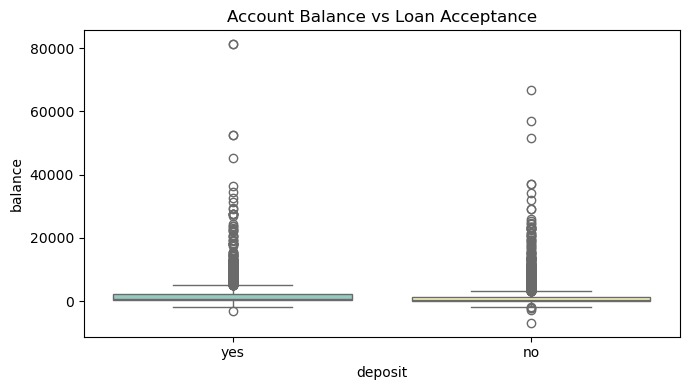

In [8]:
# Plot 5: Balance vs Loan Acceptance
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='deposit', y='balance', palette='Set3')
plt.title('Account Balance vs Loan Acceptance')
plt.tight_layout()
plt.savefig('balance_vs_loan.png')
plt.show()

In [9]:
# Encode all categorical columns using LabelEncoder
le = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print("\nEncoding done! Sample data:")
df.head()

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']

Encoding done! Sample data:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


In [10]:
# Define features (X) and target (y)
X = df.drop(columns=['deposit'])
y = df['deposit']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (8929, 16)
Testing set size: (2233, 16)


In [11]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predict
lr_pred = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 78.15 %

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.79      1166
           1       0.77      0.76      0.77      1067

    accuracy                           0.78      2233
   macro avg       0.78      0.78      0.78      2233
weighted avg       0.78      0.78      0.78      2233



In [12]:
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_pred = dt_model.predict(X_test)

# Evaluate
print("=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, dt_pred) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree ===
Accuracy: 76.31 %

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      1166
           1       0.76      0.74      0.75      1067

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233



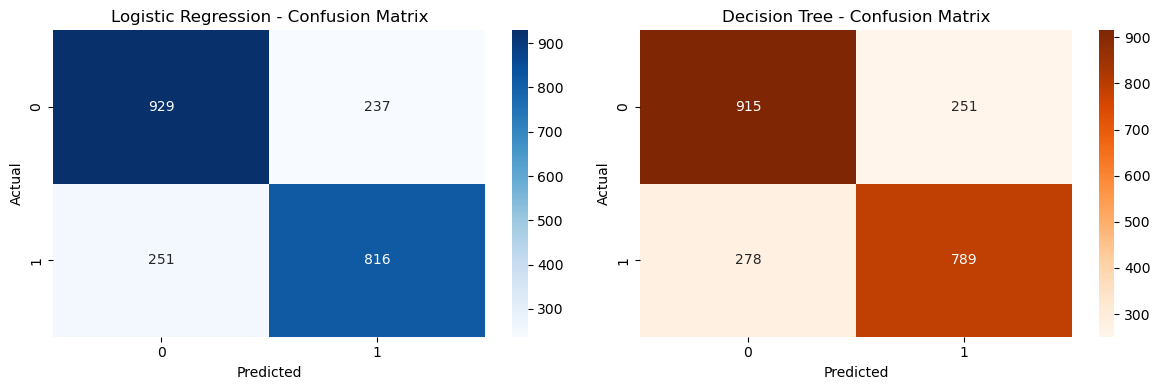

In [13]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
sns.heatmap(confusion_matrix(y_test, lr_pred),
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(confusion_matrix(y_test, dt_pred),
            annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('loan_confusion_matrices.png')
plt.show()

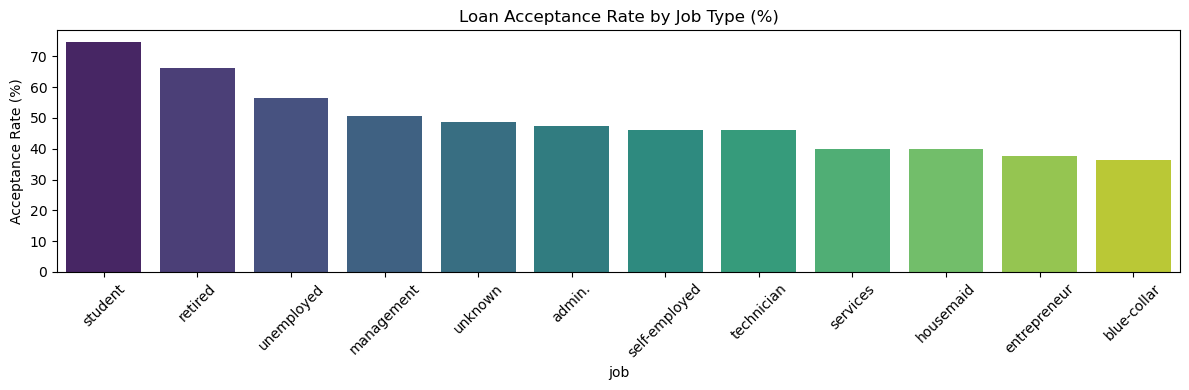

Acceptance Rate by Job:
job
student          74.72
retired          66.32
unemployed       56.58
management       50.70
unknown          48.57
admin.           47.30
self-employed    46.17
technician       46.08
services         39.98
housemaid        39.78
entrepreneur     37.50
blue-collar      36.42
Name: deposit, dtype: float64


In [14]:
# Which customer groups are more likely to accept the loan?
df_original = pd.read_csv('bank.csv')

# Acceptance rate by job
job_acceptance = df_original.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False).round(2)

plt.figure(figsize=(12, 4))
sns.barplot(x=job_acceptance.index, y=job_acceptance.values, palette='viridis')
plt.title('Loan Acceptance Rate by Job Type (%)')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('acceptance_by_job.png')
plt.show()

print("Acceptance Rate by Job:")
print(job_acceptance)

## Conclusion

- The dataset has **11,162 rows** with customer demographic and banking data.
- About **47%** of customers accepted the personal loan offer.
- **Students and retired customers** have the highest loan acceptance rates.
- Customers with **higher account balances** are more likely to accept loans.
- **Single customers** show slightly higher acceptance than married ones.
- **Decision Tree** performed slightly better than Logistic Regression on this dataset.
- The bank should target retired and student customers with higher balances for loan campaigns.